In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Loaded: {df.shape}')

Loaded: (7043, 21)


In [ ]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'NaN count in TotalCharges after conversion: {df["TotalCharges"].isnull().sum()}')
print(f'Dtype is now: {df["TotalCharges"].dtype}')

NaN count in TotalCharges after conversion: 11
Dtype is now: float64


In [ ]:

df = df.dropna(subset=['TotalCharges'])
df = df.reset_index(drop=True)

print(f'Shape after dropping: {df.shape}')
print(f'Remaining NaNs anywhere: {df.isnull().sum().sum()}')

Shape after dropping: (7032, 21)
Remaining NaNs anywhere: 0


In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f'Churn dtype: {df["Churn"].dtype}')
print(f'\nChurn value counts:\n{df["Churn"].value_counts()}')
print(f'\nOverall churn rate: {df["Churn"].mean():.3f} ({df["Churn"].mean()*100:.1f}%)')

Churn dtype: int64

Churn value counts:
Churn
0    5163
1    1869
Name: count, dtype: int64

Overall churn rate: 0.266 (26.6%)


In [ ]:
df = df.drop(columns=['customerID'])

print(f'Final shape: {df.shape}')

Final shape: (7032, 20)


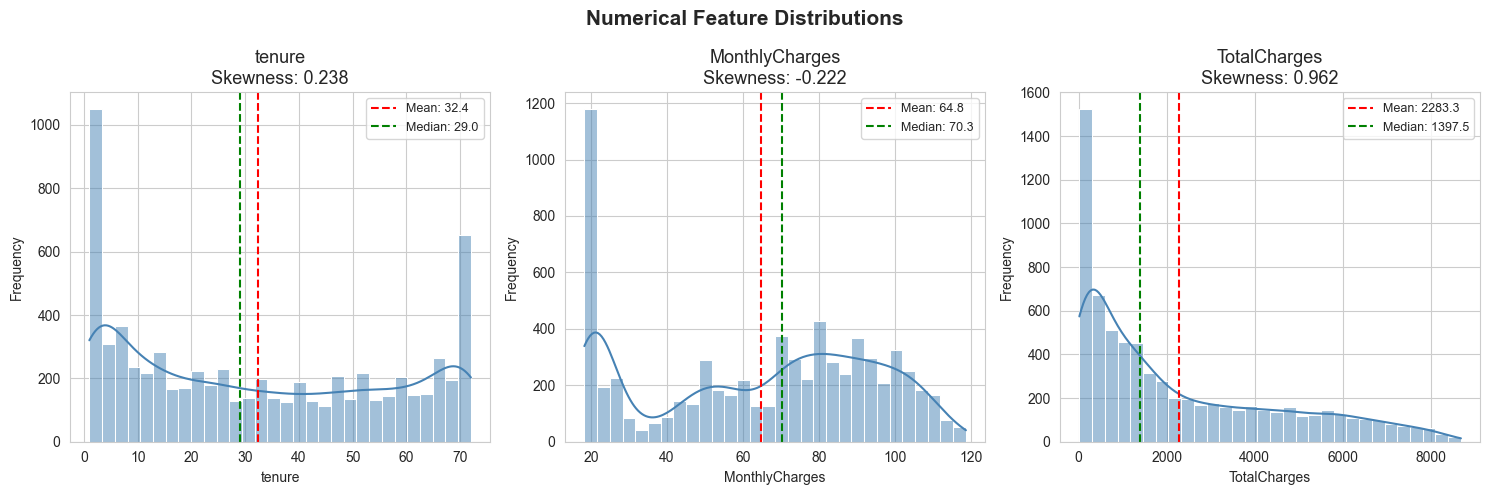

In [13]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'{col}\nSkewness: {df[col].skew():.3f}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', linewidth=1.5,
                    label=f'Median: {df[col].median():.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/02_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_3320\3540769732.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_3320\3540769732.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_3320\3540769732.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


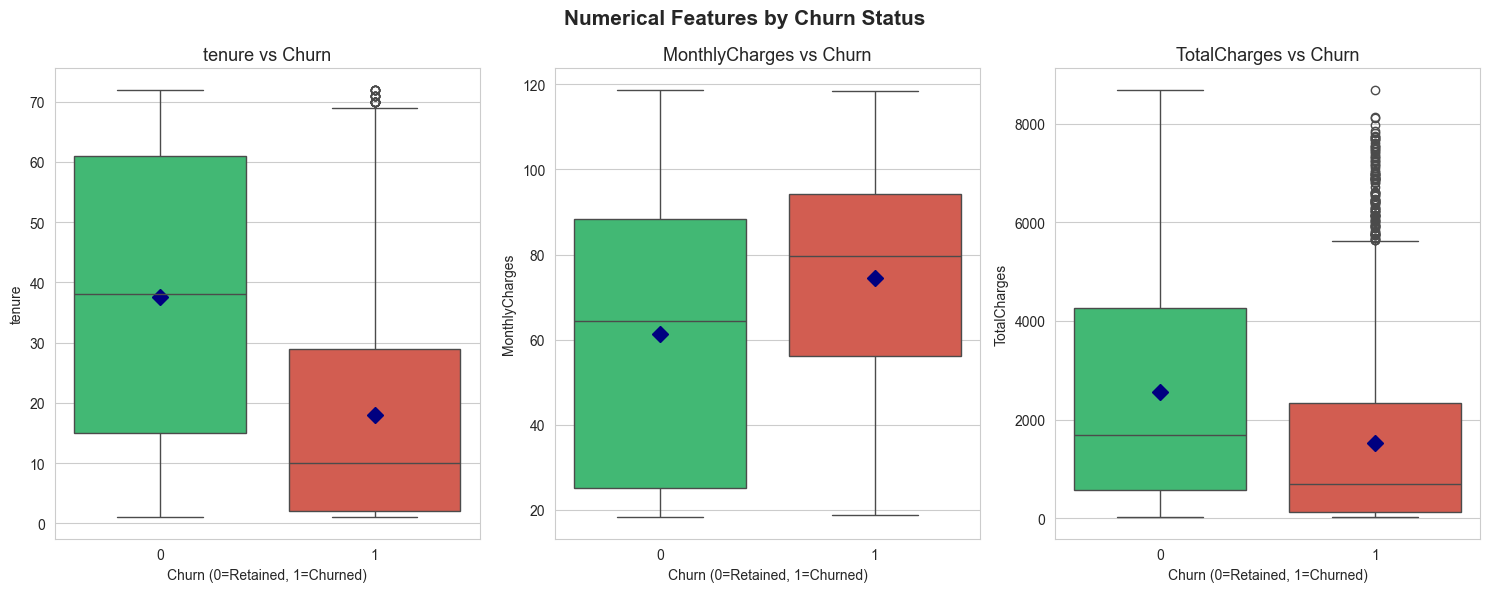

Mean values by Churn status:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
0       37.65           61.31       2555.34
1       17.98           74.44       1531.80


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        data=df, x='Churn', y=col,
        palette={'0': '#2ecc71', '1': '#e74c3c'},
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs Churn', fontsize=13)
    axes[i].set_xlabel('Churn (0=Retained, 1=Churned)')
    means = df.groupby('Churn')[col].mean()
    for churn_val, mean_val in means.items():
        axes[i].plot(churn_val, mean_val, 'D', color='navy', markersize=8)

plt.suptitle('Numerical Features by Churn Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/03_boxplots_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean values by Churn status:')
print(df.groupby('Churn')[numerical_cols].mean().round(2))

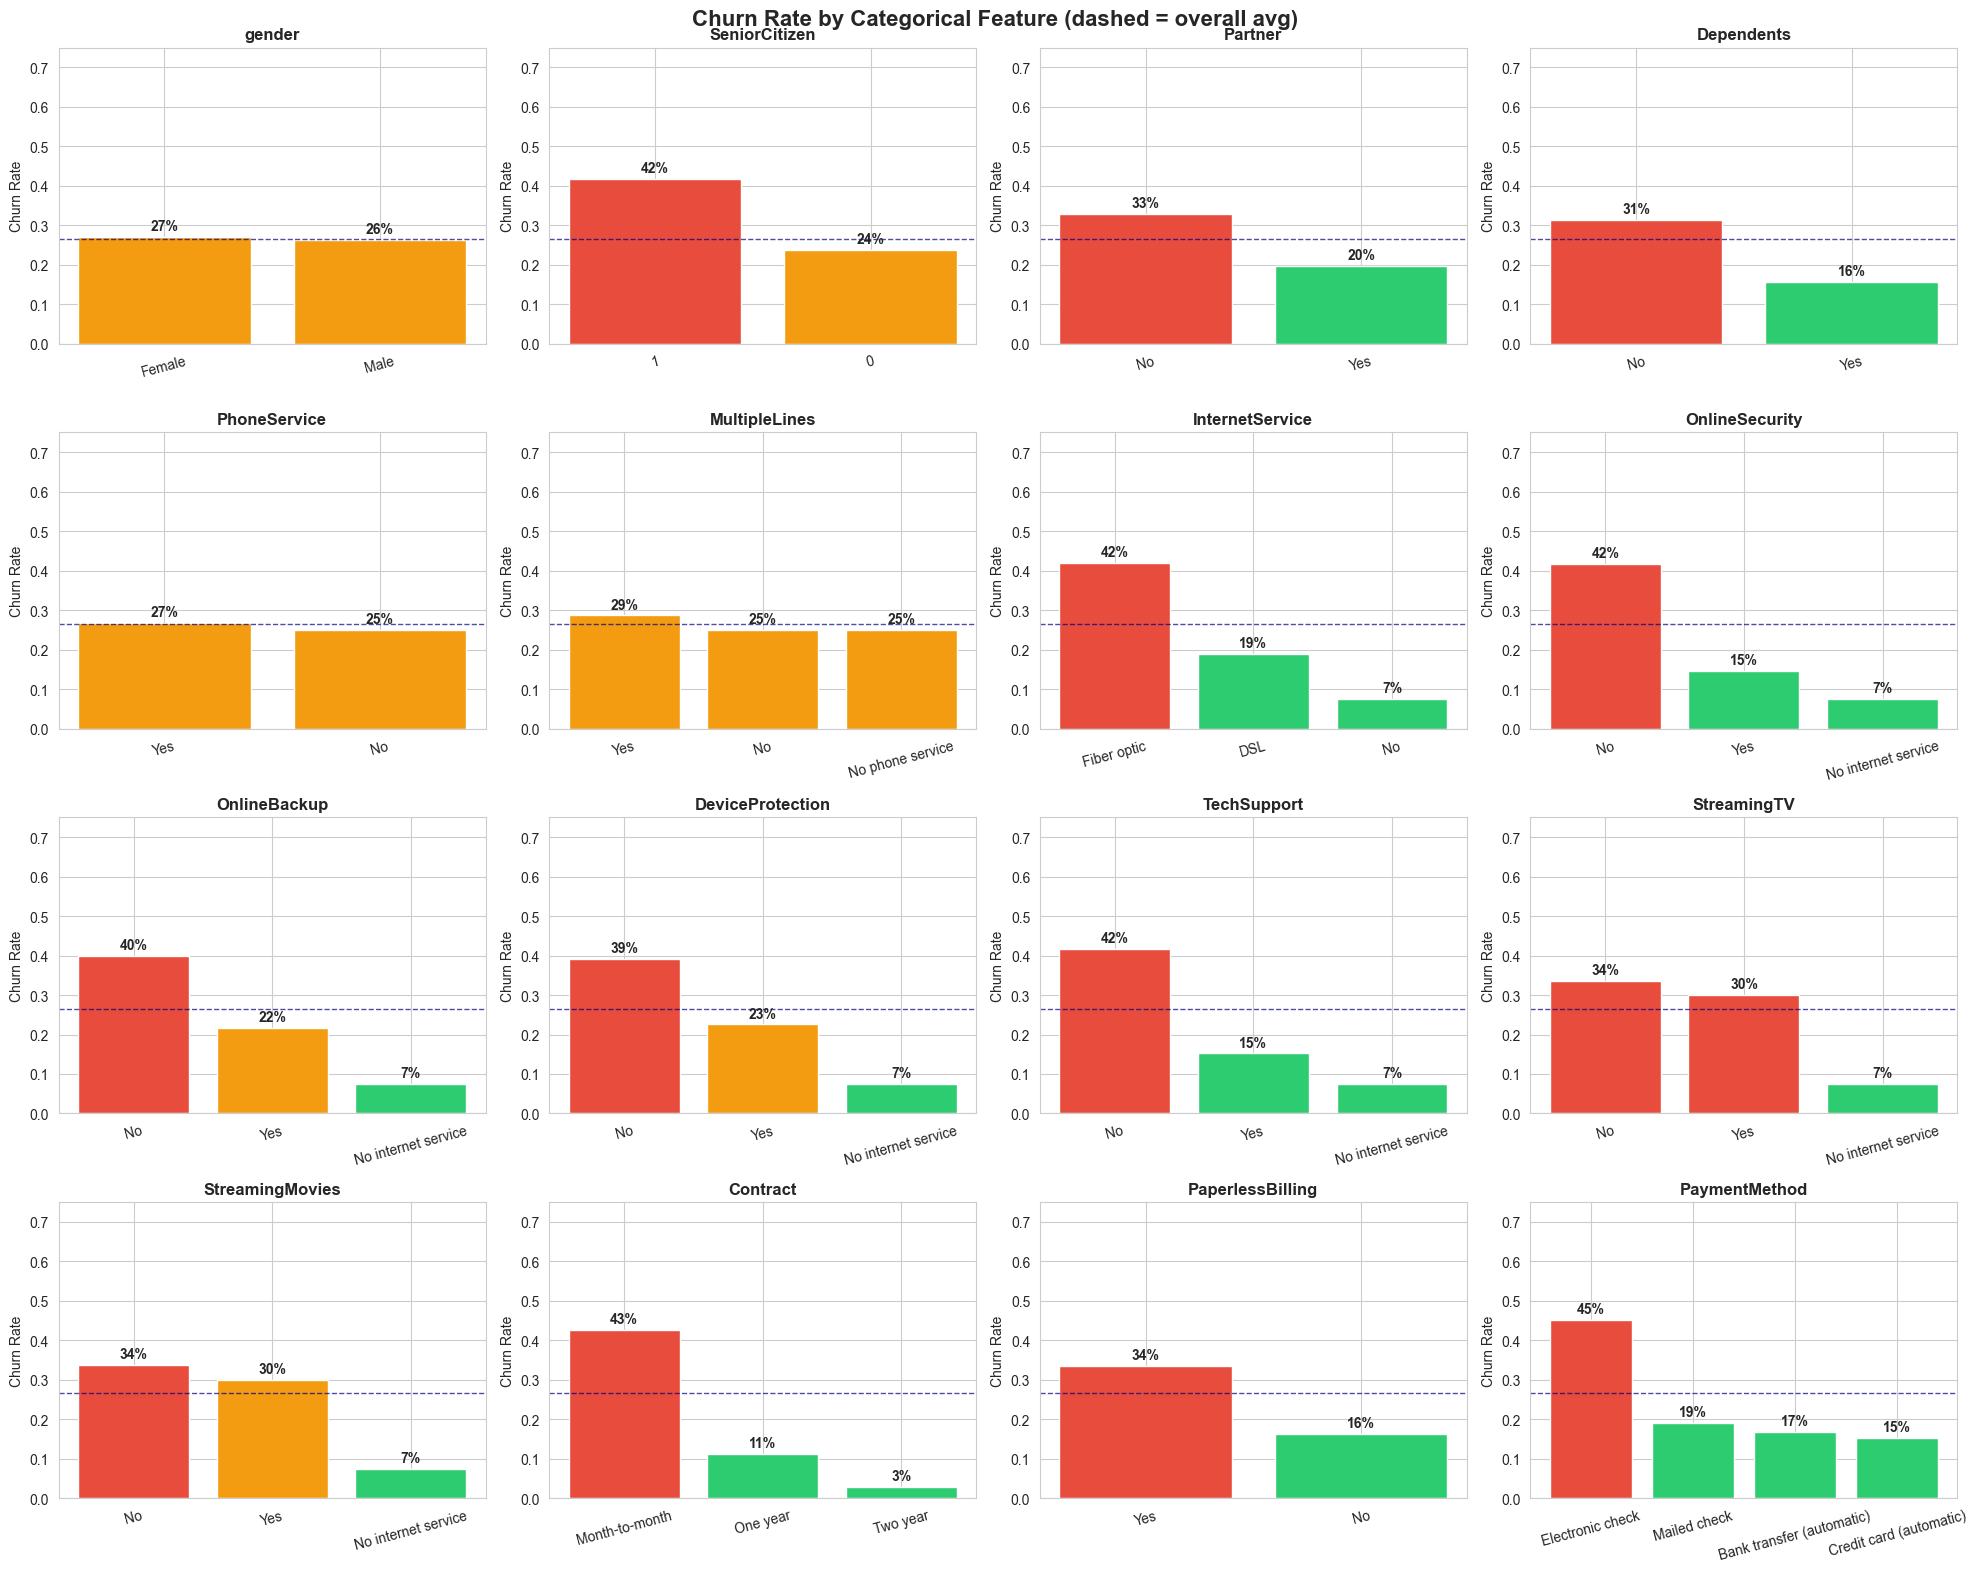

In [15]:
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

n_cols = 4
n_rows = -(-len(categorical_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

overall_churn_rate = df['Churn'].mean()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    churn_rate = churn_rate.sort_values('ChurnRate', ascending=False)

    bars = axes[i].bar(
        churn_rate[col].astype(str),
        churn_rate['ChurnRate'],
        color=['#e74c3c' if r > 0.3 else '#f39c12' if r > 0.2 else '#2ecc71'
               for r in churn_rate['ChurnRate']]
    )
    for bar, rate in zip(bars, churn_rate['ChurnRate']):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{rate:.0%}', ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_ylim(0, 0.75)
    axes[i].axhline(overall_churn_rate, color='navy', linestyle='--',
                    linewidth=1, alpha=0.7)
    axes[i].tick_params(axis='x', rotation=15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature (dashed = overall avg)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/04_churn_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

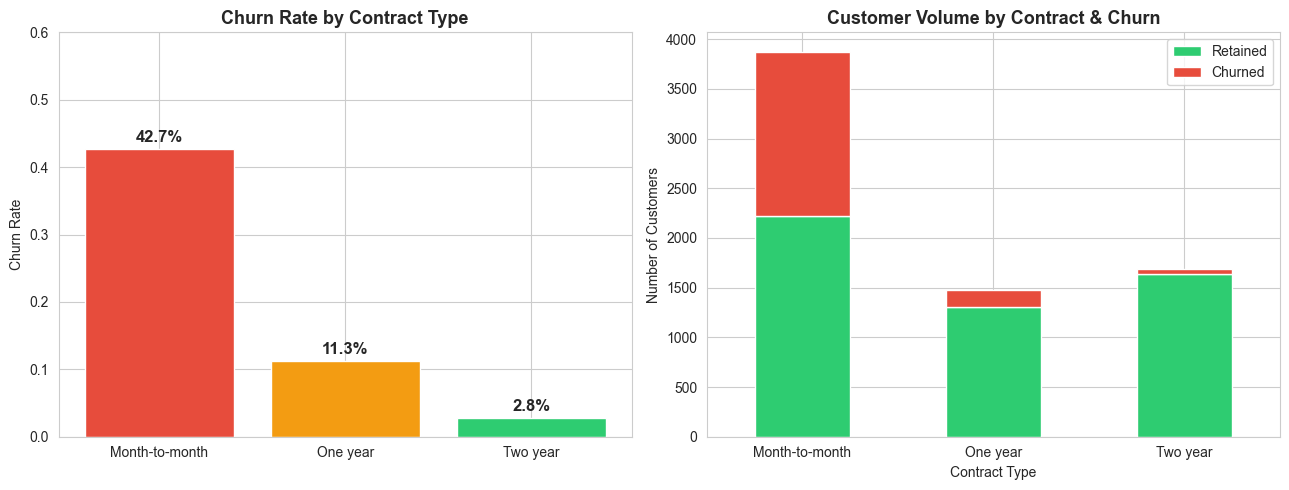

Churn rate by contract type:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: str


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Churn rate per contract type
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
bars = axes[0].bar(contract_churn.index, contract_churn.values,
                   color=['#e74c3c', '#f39c12', '#2ecc71'])
for bar, rate in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{rate:.1%}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].set_ylim(0, 0.6)

# Stacked bar — volume + composition
contract_counts = df.groupby(['Contract', 'Churn']).size().unstack()
contract_counts.columns = ['Retained', 'Churned']
contract_counts.plot(kind='bar', stacked=True, ax=axes[1],
                     color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('Customer Volume by Contract & Churn', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xlabel('Contract Type')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/05_contract_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('Churn rate by contract type:')
print(contract_churn.apply(lambda x: f'{x:.1%}'))

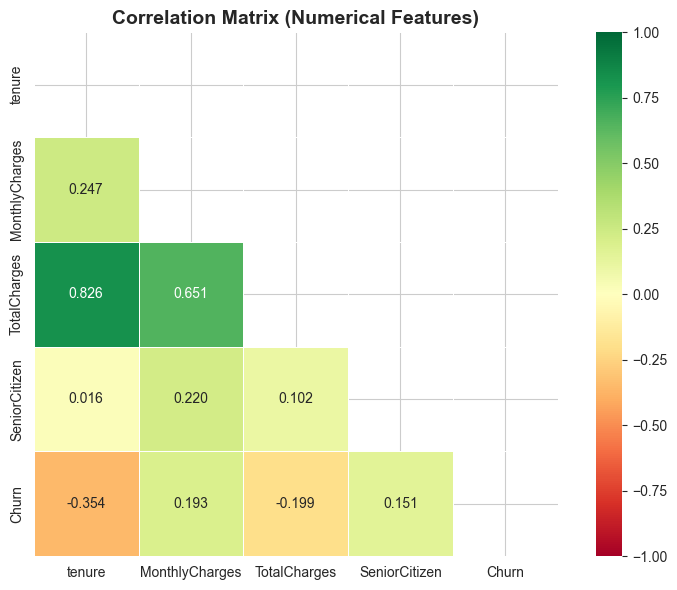

Correlation with Churn:
MonthlyCharges     0.193
SeniorCitizen      0.151
TotalCharges      -0.199
tenure            -0.354
Name: Churn, dtype: str


In [17]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f',
    cmap='RdYlGn', mask=mask,
    vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title('Correlation Matrix (Numerical Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with Churn:')
print(corr_matrix['Churn'].sort_values(ascending=False).drop('Churn').apply(lambda x: f'{x:.3f}'))

In [18]:
# All future notebooks load from processed/ — not the raw file
df.to_csv('../data/processed/telco_churn_cleaned.csv', index=False)

print('Saved: data/processed/telco_churn_cleaned.csv')
print(f'Shape: {df.shape}')
print(f'\nDtype counts:\n{df.dtypes.value_counts()}')

Saved: data/processed/telco_churn_cleaned.csv
Shape: (7032, 20)

Dtype counts:
str        15
int64       3
float64     2
Name: count, dtype: int64
